In [1]:
import pandas as pd

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix ,classification_report
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv("500hits.csv", encoding= 'latin-1')

In [4]:
df = df.drop(columns = ['PLAYER','CS'])

In [5]:
df.columns

Index(['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB',
       'BA', 'HOF'],
      dtype='str')

In [6]:
X = df.iloc[:, 0:13]     #X is our data with the output(HOF) so we slicing the data leaving HOF behind

In [7]:
X.head(10)

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,BA
0,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,0.366
1,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,0.331
2,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,0.345
3,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,0.310
4,21,2792,10430,1736,3430,640,252,101,0,963,327,722,0.329
5,23,3308,11988,1816,3419,646,59,452,1844,1845,1393,168,0.285
6,21,2683,10835,1782,3319,605,114,234,1307,1094,1244,504,0.306
7,25,2826,9949,1821,3315,438,187,47,520,1499,286,744,0.333
8,22,2992,10881,2062,3283,523,140,660,1903,1464,1526,338,0.302
9,21,3026,11336,1627,3255,560,35,504,1917,1333,1516,110,0.287


In [8]:
X.columns

Index(['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB',
       'BA'],
      dtype='str')

In [9]:
y = df.iloc[:, 13]   #only the HOF

In [22]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: HOF, dtype: int64

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state= 11, test_size= 0.2)

In [11]:
scaler  =  MinMaxScaler(feature_range=(0,1))

feature scaling but only on the input data X

In [12]:
X_train = scaler.fit_transform(X_train)

In [13]:
X_test = scaler.fit_transform(X_test)

MAKING THE MODEL 

In [14]:
knn = KNeighborsClassifier(n_neighbors=8)

In [15]:
knn.fit(X_train,y_train) #in this step , model is being trained so we gonna feed the training data

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [16]:
y_pred = knn.predict(X_test)
#take this testing data (X_test) and make predictions and put those predictions in array named y_pred

In [17]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1])

In [ ]:
knn.score(X_test,y_test)
#Take these test inputs (X_test), make your predictions, and compare them against the correct answers (y_test). Then give me your score  

0.8279569892473119

In [ ]:
knn.predict([[2,2,2,2,2,2,2,2,2,2,2,2,2]]) #can predict specific column like that but have to give every column value

array([1])

In [ ]:
cm  = confusion_matrix(y_test,y_pred)    #gives a matrix which gives no. of right and wrong predictions

In [ ]:
cm

array([[55, 12],
       [ 4, 22]])

VISUALIZING THE CONFUSION MATRIX

Text(50.83333333333333, 0.5, 'truth')

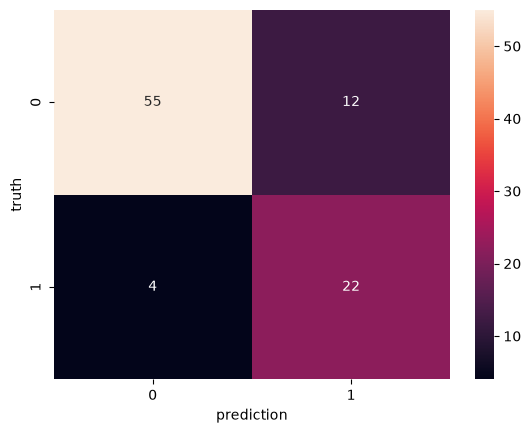

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot = True)
plt.xlabel("prediction")
plt.ylabel("truth")

In [ ]:
cr = classification_report(y_test,y_pred)

In [ ]:
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        67
           1       0.65      0.85      0.73        26

    accuracy                           0.83        93
   macro avg       0.79      0.83      0.80        93
weighted avg       0.85      0.83      0.83        93

